In [1]:
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt

In [2]:
orders = pd.read_csv("../data/cleaned/orders_clean.csv")

In [3]:
orders.head()

,OrderID,OrderDate,CustomerID,ProductID,Quantity,Discount,Sales,Profit,Month,Year,Quarter,ProfitMargin,AverageOrderValue
0,O001,2024-03-09,C002,P040,1,696,2739,1223,3,2024,1,44.651333,2739.000000
1,O002,2024-03-26,C015,P009,5,1482,15193,8403,3,2024,1,55.308366,3038.600000
2,O003,2024-05-02,C029,P025,3,1132,51965,9368,5,2024,2,18.027519,17321.666667
3,O004,2024-02-24,C032,P020,2,1154,4252,1438,2,2024,1,33.819379,2126.000000
4,O005,2024-05-12,C029,P027,1,1316,53615,11859,5,2024,2,22.118810,53615.000000


In [4]:
orders["OrderDate"] = pd.to_datetime(orders["OrderDate"])

In [5]:
daily_sales = (
    orders.groupby("OrderDate")["Sales"]
    .sum()
    .reset_index()
)

In [6]:
forecast_data = daily_sales.rename(
    columns={
        "OrderDate":"ds",
        "Sales":"y"
    }
)

In [7]:
forecast_data.head()

,ds,y
0,2024-01-06,2180
1,2024-01-07,60784
2,2024-01-09,3035
3,2024-01-16,57774
4,2024-01-18,74480


In [8]:
model = Prophet()

In [9]:
model.fit(forecast_data)

17:01:02 - cmdstanpy - INFO - Chain [1] start processing
17:01:04 - cmdstanpy - INFO - Chain [1] done processing


In [10]:
future = model.make_future_dataframe(
    periods=365
)

In [11]:
future.tail()

,ds
404,2025-06-08
405,2025-06-09
406,2025-06-10
407,2025-06-11
408,2025-06-12


In [12]:
forecast = model.predict(future)

In [13]:
forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2024-01-06,45957.751213,-7414.702189,133831.216837,45957.751213,45957.751213,15129.153445,15129.153445,15129.153445,15129.153445,15129.153445,15129.153445,0.0,0.0,0.0,61086.904658
1,2024-01-07,45929.625399,-20618.119237,120986.872043,45929.625399,45929.625399,4087.949205,4087.949205,4087.949205,4087.949205,4087.949205,4087.949205,0.0,0.0,0.0,50017.574604
2,2024-01-09,45873.373769,-19602.704716,123197.473699,45873.373769,45873.373769,2905.451658,2905.451658,2905.451658,2905.451658,2905.451658,2905.451658,0.0,0.0,0.0,48778.825427
3,2024-01-16,45676.493063,-18188.686164,123784.482129,45676.493063,45676.493063,2905.451658,2905.451658,2905.451658,2905.451658,2905.451658,2905.451658,0.0,0.0,0.0,48581.944721
4,2024-01-18,45620.241435,-43737.242812,92327.594025,45620.241435,45620.241435,-18684.986370,-18684.986370,-18684.986370,-18684.986370,-18684.986370,-18684.986370,0.0,0.0,0.0,26935.255065


In [14]:
forecast[
    [
        "ds",
        "yhat",
        "yhat_lower",
        "yhat_upper"
    ]
].tail()

,ds,yhat,yhat_lower,yhat_upper
404,2025-06-08,35448.402305,-36177.525349,105230.611288
405,2025-06-09,65054.114298,-3431.900529,132529.510002
406,2025-06-10,34209.653128,-36452.438941,107057.214457
407,2025-06-11,9580.527785,-56674.294846,77249.633520
408,2025-06-12,12562.963471,-52917.144024,82776.799759


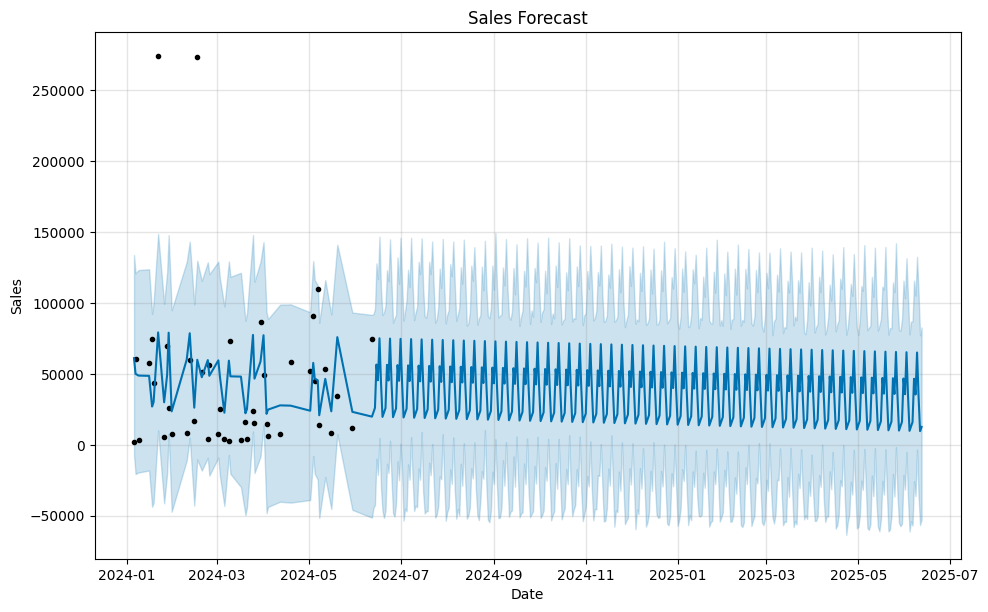

In [15]:
fig = model.plot(forecast)

plt.title("Sales Forecast")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.show()

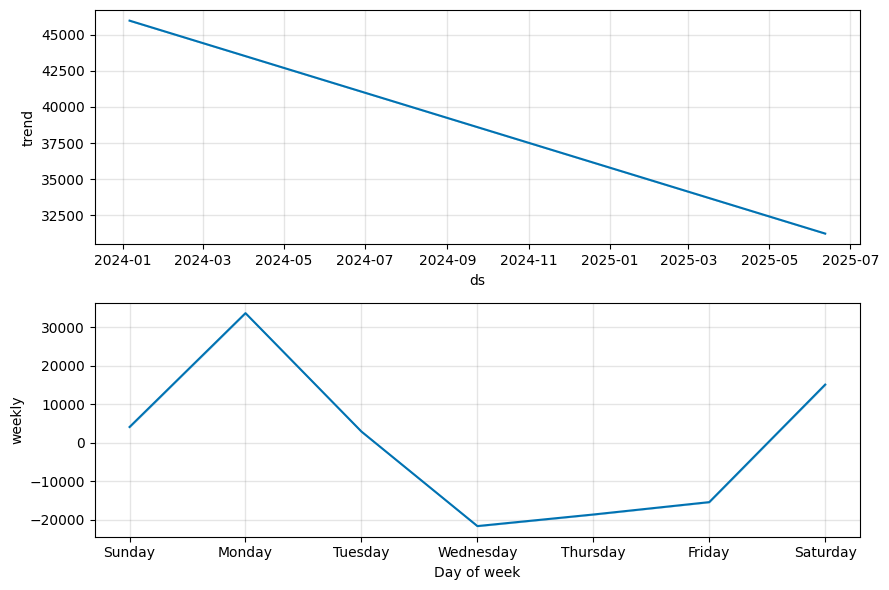

In [16]:
fig2 = model.plot_components(forecast)

In [18]:
forecast.to_csv(
    "../reports/sales_forecast.csv",
    index=False
)

In [19]:
import joblib

joblib.dump(
    model,
    "../models/forecast_model.pkl"
)

['../models/forecast_model.pkl']

In [20]:
forecast_model = joblib.load(
    "../models/forecast_model.pkl"
)

17:05:19 - cmdstanpy - INFO - Chain [1] start processing
17:05:19 - cmdstanpy - INFO - Chain [1] done processing


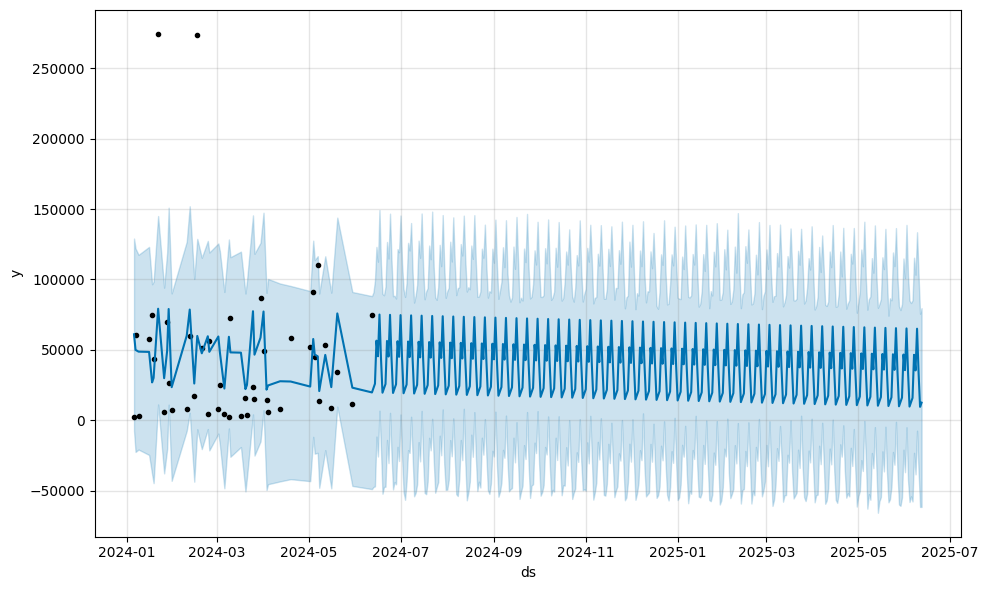

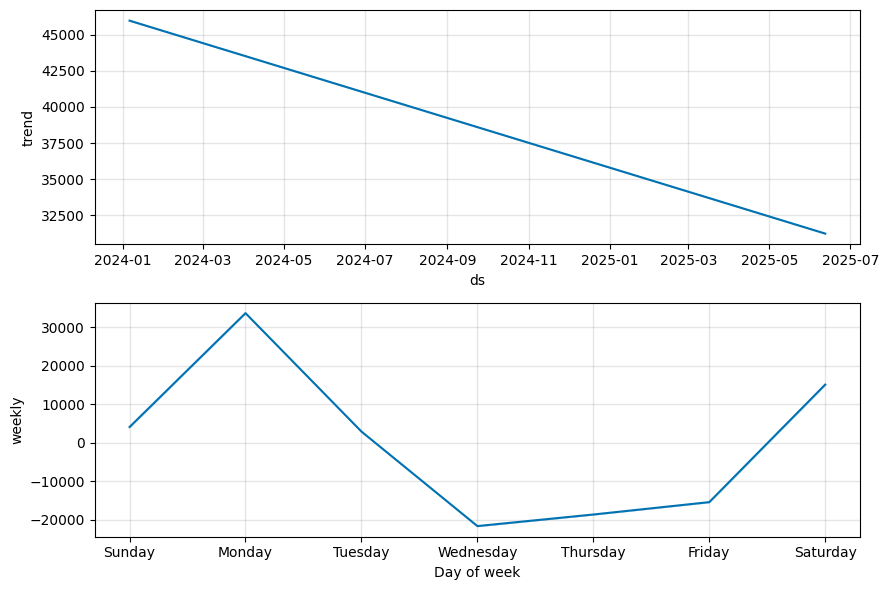

In [22]:
# All code in one file
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt
import joblib

# Load data
orders = pd.read_csv("../data/cleaned/orders_clean.csv")
orders["OrderDate"] = pd.to_datetime(orders["OrderDate"])

# Aggregate daily sales
daily_sales = (
    orders.groupby("OrderDate")["Sales"]
    .sum()
    .reset_index()
)

# Prophet format
forecast_data = daily_sales.rename(
    columns={
        "OrderDate": "ds",
        "Sales": "y"
    }
)

# Train
model = Prophet()
model.fit(forecast_data)

# Future dates
future = model.make_future_dataframe(periods=365)

# Predict
forecast = model.predict(future)

# Save outputs
forecast.to_csv(
    "../reports/sales_forecast.csv",
    index=False
)

joblib.dump(
    model,
    "../models/forecast_model.pkl"
)

# Visualize
model.plot(forecast)
plt.show()

model.plot_components(forecast)
plt.show()